In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = "../data/processed/processed_data.csv"
df = pd.read_csv(DATA_PATH)
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

In [ ]:
events_df = df[df['record_type']=='event'].copy()
events_df['event_date'] = pd.to_datetime(events_df['observation_date'], errors='coerce')

impact_links_df = df[df['record_type']=='impact_link'].copy()

In [ ]:
merged_df[[
    'parent_id_impact',
    'pillar_impact',
    'related_indicator_impact',
    'impact_direction_impact',
    'impact_magnitude_impact',
    'lag_months_impact',
    'event_date_event',
    'category_event',
    'event_name_event'
]].head()


,parent_id_impact,pillar_impact,related_indicator_impact,impact_direction_impact,impact_magnitude_impact,lag_months_impact,event_date_event,category_event,event_name_event
0,EVENT_FAYDA_2023,access,ACC_OWNERSHIP,positive,0.02,18.0,NaT,NaN,NaN


In [ ]:
impact_links_df['parent_id'] = impact_links_df['parent_id'].astype(str)
events_df['id'] = events_df['id'].astype(str)

In [ ]:
impact_links_df['parent_id'] = impact_links_df['parent_id'].str.strip()
events_df['id'] = events_df['id'].str.strip()

In [ ]:
merged_df = impact_links_df.merge(
    events_df,
    left_on='parent_id',
    right_on='id',
    suffixes=('_impact', '_event')
)

print(merged_df[['event_name_event', 'related_indicator_impact', 'impact_magnitude_impact']].head())


                    event_name_event related_indicator_impact  \
0  Fayda Digital ID National Rollout            ACC_OWNERSHIP   

   impact_magnitude_impact  
0                     0.02  


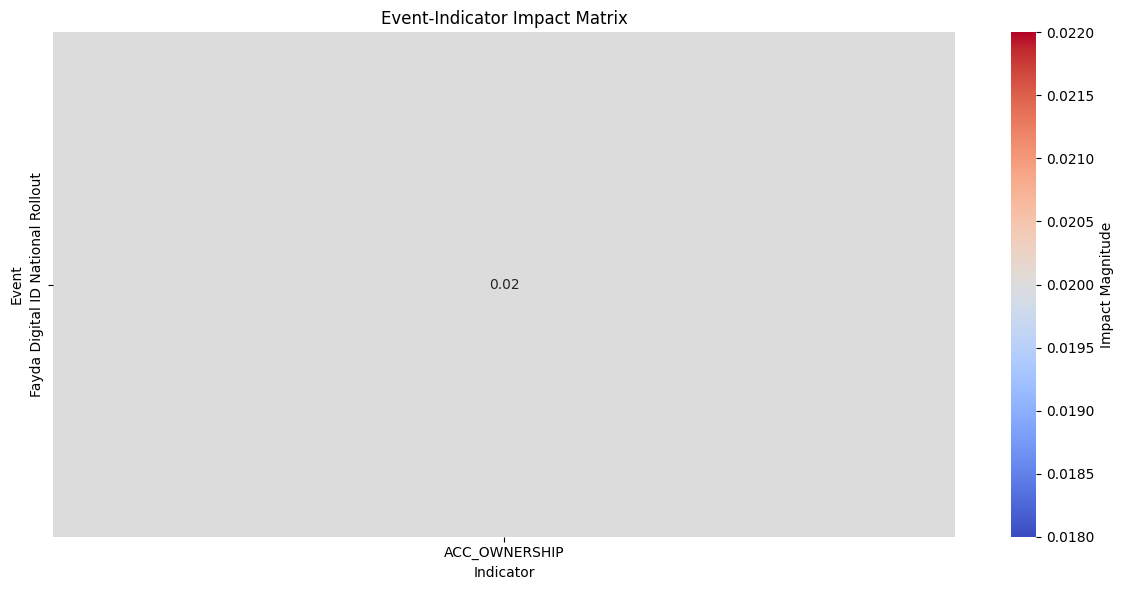

In [ ]:

impact_links_df['parent_id'] = impact_links_df['parent_id'].astype(str).str.strip()
events_df['id'] = events_df['id'].astype(str).str.strip()

merged_df = impact_links_df.merge(
    events_df,
    left_on='parent_id',
    right_on='id',
    suffixes=('_impact', '_event')
)

valid_impacts = merged_df.dropna(subset=['impact_magnitude_impact'])

assoc_matrix = valid_impacts.pivot_table(
    index='event_name_event',            # Events as rows
    columns='related_indicator_impact',  # Indicators as columns
    values='impact_magnitude_impact',    # Impact values
    aggfunc='first'
)

assoc_matrix = assoc_matrix.fillna(0)

plt.figure(figsize=(12, max(6, len(assoc_matrix)*0.5)))
sns.heatmap(
    assoc_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar_kws={'label':'Impact Magnitude'}
)
plt.title("Event-Indicator Impact Matrix")
plt.ylabel("Event")
plt.xlabel("Indicator")
plt.tight_layout()
plt.show()

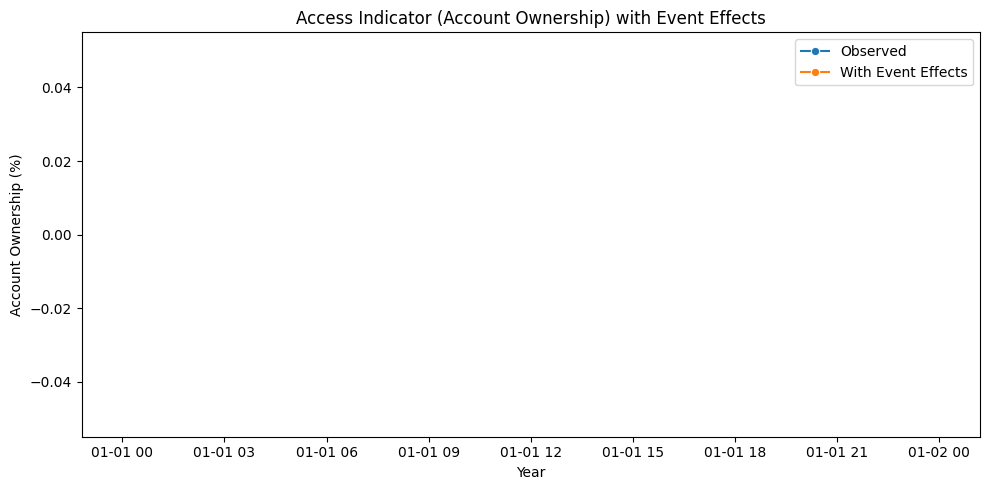

In [ ]:
# Ensure observation_date is datetime
access_df['observation_date'] = pd.to_datetime(access_df['observation_date'])
merged_df['event_date_event'] = pd.to_datetime(merged_df['event_date_event'])

# Initialize cumulative event effect
access_df['event_effect'] = 0

# Apply each event impact to Access indicator
for idx, row in merged_df.iterrows():
    indicator = row['related_indicator_impact']
    if indicator not in access_df['indicator_code'].values:
        continue
    
    impact = row['impact_magnitude_impact']
    lag = row['lag_months'] if not pd.isna(row['lag_months']) else 0
    event_date = row['event_date_event'] + pd.DateOffset(months=int(lag))
    
    access_df.loc[access_df['observation_date'] >= event_date, 'event_effect'] += impact

# Adjusted value
access_df['adjusted_value'] = access_df['value_numeric'] + access_df['event_effect']

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=access_df, x='observation_date', y='value_numeric', marker='o', label='Observed')
sns.lineplot(data=access_df, x='observation_date', y='adjusted_value', marker='o', label='With Event Effects')
plt.title("Access Indicator (Account Ownership) with Event Effects")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
usage_df = df[df['pillar'] == 'usage'].sort_values('observation_date').copy()

# Ensure observation_date is datetime
usage_df['observation_date'] = pd.to_datetime(usage_df['observation_date'])
merged_df['event_date_event'] = pd.to_datetime(merged_df['event_date_event'])

# Strip whitespace and lowercase for alignment
usage_df['indicator_code'] = usage_df['indicator_code'].str.strip().str.lower()
merged_df['related_indicator_impact'] = merged_df['related_indicator_impact'].str.strip().str.lower()

# Initialize cumulative event effect
usage_df['event_effect'] = 0

# Apply each event impact to Usage indicator
for idx, row in merged_df.iterrows():
    indicator = row['related_indicator_impact']
    
    # Only apply impact if the indicator matches Usage observations
    if indicator not in usage_df['indicator_code'].values:
        continue
    
    impact = row['impact_magnitude_impact']
    lag = row['lag_months'] if not pd.isna(row['lag_months']) else 0
    event_date = row['event_date_event'] + pd.DateOffset(months=int(lag))
    
    # Apply impact to all observations after the event date
    usage_df.loc[usage_df['observation_date'] >= event_date, 'event_effect'] += impact

# Create adjusted value with event impacts
usage_df['adjusted_value'] = usage_df['value_numeric'] + usage_df['event_effect']